In [ ]:
!pip install transformers --quiet

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, ToTensor, Resize
import torch.nn.functional as F

import torchmetrics
from torchmetrics.classification import BinaryAccuracy
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
from tqdm import tqdm
from glob import glob
import torch.optim as optim
from torch import optim, nn
from torchmetrics.segmentation import GeneralizedDiceScore, MeanIoU
import warnings
from PIL import Image
import shutil
import random
import copy
from torch.utils.tensorboard import SummaryWriter
from transformers import SegformerForSemanticSegmentation

warnings.filterwarnings("ignore")

2026-05-15 10:03:29.372857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778839409.610166      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778839409.678882      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778839410.208861      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778839410.208904      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778839410.208907      23 computation_placer.cc:177] computation placer alr

In [ ]:
def get_camo_image_mask_pairs(base_path, dataset_type='Train'):
    image_mask_pairs = []

    img_dir = os.path.join(base_path, 'Images', dataset_type)
    mask_dir = os.path.join(base_path, 'GT')

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        print(f"Đường dẫn không tồn tại: Cần kiểm tra lại {img_dir} hoặc {mask_dir}")
        return []

    images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

    for img_name in images:
        base_name = os.path.splitext(img_name)[0]
        mask_name = base_name + '.png'

        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            image_mask_pairs.append((img_path, mask_path))

    return image_mask_pairs

def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(20, 10))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()

class CamoDataset(Dataset):
    def __init__(self, root, image_set="Train", transform=None):
        self.root = root
        self.image_set = image_set
        self.transform = transform
        self.image_mask_pairs = get_camo_image_mask_pairs(root, image_set)

    def __len__(self):
        return len(self.image_mask_pairs)

    def __getitem__(self, item):
        img_path, mask_path = self.image_mask_pairs[item]

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Đưa mask về chuẩn [0, 1] và ép kiểu LongTensor cho Segformer
        if isinstance(mask, torch.Tensor):
            mask = torch.where(mask > 127, 1, 0).long()
        else:
            mask = np.where(mask > 127, 1, 0).astype(np.int64)
            mask = torch.from_numpy(mask)

        return img, mask

In [ ]:
def img_transform(trainsize=256):
    train_transform = A.Compose([
        A.Rotate(limit=15, p=0.5),
        A.RandomScale([0.5, 2]),
        A.GaussianBlur(),
        A.HorizontalFlip(p=0.5),
        A.GaussNoise(var_limit=(10, 50), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.3),
        A.Resize(width=trainsize, height=trainsize),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
        ToTensorV2(),
    ])

    test_transform = A.Compose([
        A.Resize(width=trainsize, height=trainsize),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
        ToTensorV2(),
    ])
    return train_transform, test_transform

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best_weights=False):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ""

    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif self.best_loss - val_loss > self.min_delta:
            self.best_model = copy.deepcopy(model.state_dict())
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.status = f"Stop on {self.counter}"
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model)
                return True
        self.status = f"{self.counter}/{self.patience}"
        return False

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [ ]:
def train(model, train_dataloader, device, optimizer, epoch, EPOCHS, writer, train_loss_meter, criterion):
    model.train()
    train_progress = tqdm(train_dataloader, colour="cyan")

    for idx, img_mask in enumerate(train_progress):
        optimizer.zero_grad()
        img = img_mask[0].to(device).float()
        masks = img_mask[1].to(device)

        masks = (masks > 0).long()

        y_hat = model(img).logits
        y_hat = F.interpolate(y_hat, masks.shape[1:], mode="bilinear", align_corners=False)

        loss = criterion(y_hat, masks)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            train_loss_meter.update(loss.item())
            writer.add_scalar("Train/Loss", train_loss_meter.avg, epoch * len(train_dataloader) + idx)

        train_progress.set_description("TRAIN| Epoch: {}/{}| Iter: {}/{} | Loss: {:0.4f} | lr: {}".format(
            epoch + 1, EPOCHS, idx + 1, len(train_dataloader), loss.item(), optimizer.param_groups[0]['lr']))

def evaluate(model, val_dataloader, device, num_classes, intersection_meter, union_meter, target_meter):
    model.eval()
    with torch.no_grad():
        for idx, img_mask in enumerate(val_dataloader):
            img = img_mask[0].to(device).float()
            mask = img_mask[1].to(device)
            mask = (mask > 0).long()

            y_hat = model(img).logits
            y_hat = F.interpolate(y_hat, size=mask.shape[1:], mode="bilinear", align_corners=False)
            y_hat = y_hat.squeeze(1)
            y_hat_mask = y_hat.argmax(dim=1)

            intersection, union, target = intersectionAndUnionGPU(y_hat_mask, mask, num_classes)
            intersection, union, target = intersection.cpu().numpy(), union.cpu().numpy(), target.cpu().numpy()

            intersection_meter.update(intersection)
            union_meter.update(union)
            target_meter.update(target)

            if idx > 40: # Tuỳ chỉnh giới hạn batch đánh giá nếu cần
                break

    accuracy_class = intersection_meter.sum / (target_meter.sum + 1e-10)
    iou_class = intersection_meter.sum / (union_meter.sum + 1e-10)
    dice_class = (2 * intersection_meter.sum) / (intersection_meter.sum + union_meter.sum + 1e-10)

    macc = np.mean(accuracy_class)
    miou = np.mean(iou_class)
    mdice = np.mean(dice_class)

    return macc, miou, mdice

In [ ]:
def main(learning_rate, batch_size, epochs, num_workers, data_path, model_save_path, tensorboard_path, num_classes):
    if not os.path.isdir(model_save_path):
        os.makedirs(model_save_path)

    if os.path.isdir(tensorboard_path):
        shutil.rmtree(tensorboard_path)
    os.makedirs(tensorboard_path)

    train_transform, test_transform = img_transform()

    # Sử dụng CamoDataset
    train_dataset = CamoDataset(root=data_path, image_set="Train", transform=train_transform)
    valid_dataset = CamoDataset(root=data_path, image_set="Test", transform=test_transform)

    train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_dataloader = DataLoader(dataset=valid_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b4-finetuned-ade-512-512",
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_predict = -1
    current_epoch = 0

    train_loss_meter = AverageMeter()
    intersection_meter = AverageMeter()
    union_meter = AverageMeter()
    target_meter = AverageMeter()

    es = EarlyStopping(patience=14, restore_best_weights=False)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=4, threshold=1e-4, min_lr=0)
    writer = SummaryWriter(tensorboard_path)

    for epoch in range(current_epoch, epochs):
        train_loss_meter.reset()
        intersection_meter.reset()
        union_meter.reset()
        target_meter.reset()

        train(model, train_dataloader, device, optimizer, epoch, epochs, writer, train_loss_meter, criterion)
        acc, miou, dice = evaluate(model, val_dataloader, device, num_classes, intersection_meter, union_meter, target_meter)

        writer.add_scalar("Test/Acc", acc, epoch)
        writer.add_scalar("Test/mIOU", miou, epoch)
        writer.add_scalar("Test/Dice", dice, epoch)

        scheduler.step(1 - miou)

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "optimizer_state_dict": optimizer.state_dict(),
            "dice": dice
        }

        torch.save(checkpoint, os.path.join(model_save_path, "model_last.pth"))

        if miou > best_predict:
            torch.save(checkpoint, os.path.join(model_save_path, "model_best.pth"))
            best_predict = miou

        if es(model, 1 - miou):
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

        print("VAL| Acc:{:0.4f} | mIOU: {:0.4f} | Dice: {:0.4f} | EStop: {}".format(acc, miou, dice, es.status))

In [ ]:
if __name__ == '__main__':
    learning_rate = 1e-4
    batch_size = 16
    epochs = 100
    num_workers = 2 # Nên set cứng 2 hoặc 4 trên Kaggle thay vì os.cpu_count() để tránh lỗi bộ nhớ

    # Cập nhật đường dẫn chuẩn của CAMO
    data_path = "/kaggle/input/datasets/quanganhnguynquc/camodataset/CAMO-V.1.0-CVIU2019"

    model_save_path = "/kaggle/working/trained_model"
    tensorboard_path = "/kaggle/working/tensorboard"
    num_classes = 2

    main(learning_rate, batch_size, epochs, num_workers, data_path, model_save_path, tensorboard_path, num_classes)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/257M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

VAL| Acc:0.8752 | mIOU: 0.8014 | Dice: 0.8847 | EStop: 12/14


TRAIN| Epoch: 20/100| Iter: 63/63 | Loss: 0.1196 | lr: 1.0000000000000002e-06: 100%|██████████| 63/63 [11:56<00:00, 11.37s/it]


VAL| Acc:0.8745 | mIOU: 0.8009 | Dice: 0.8844 | EStop: 13/14


TRAIN| Epoch: 21/100| Iter: 63/63 | Loss: 0.1084 | lr: 1.0000000000000002e-06: 100%|██████████| 63/63 [05:00<00:00,  4.77s/it]


Early stopping triggered at epoch 21


In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

unorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

def pred_show_image_grid(model_pth, device, test_transform, num_classes, num_imgs, data_path):
    # Đã thêm weights_only=False để bypass hệ thống bảo mật của PyTorch 2.6+
    checkpoint = torch.load(model_pth, weights_only=False)

    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b4-finetuned-ade-512-512",
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    # Sử dụng CamoDataset cho tập Test
    image_dataset = CamoDataset(root=data_path, image_set="Test", transform=test_transform)

    if isinstance(num_imgs, int):
        selected_ids = np.random.choice(len(image_dataset), num_imgs, replace=False)
    else:
        selected_ids = num_imgs

    images, orig_masks, pred_masks = [], [], []
    with torch.no_grad():
        for idx in selected_ids:
            ori_img, mask = image_dataset[idx]

            y_predict = F.interpolate(model(ori_img.unsqueeze(0).to(device)).logits, size=mask.shape, mode="bilinear", align_corners=False).argmax(dim=1).squeeze()
            y_predict = y_predict.cpu().numpy()

            orig_masks.append(mask.cpu().numpy() if isinstance(mask, torch.Tensor) else mask)
            pred_masks.append(y_predict)
            images.append(unorm(ori_img).permute(1, 2, 0).cpu().numpy())

    print(f"Selected Image IDs: {selected_ids}")

    num_selected = len(selected_ids)
    fig, axes = plt.subplots(3, num_selected, figsize=(20, 10))

    # Xử lý trường hợp chỉ hiển thị 1 ảnh (axes sẽ là mảng 1D thay vì 2D)
    if num_selected == 1:
        axes = axes.reshape(-1, 1)

    titles = ["Original Image", "Ground Truth Mask", "Predicted Mask"]

    for i in range(num_selected):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(titles[0] if i == 0 else "")

        axes[1, i].imshow(orig_masks[i], cmap='gray')
        axes[1, i].set_title(titles[1] if i == 0 else "")

        axes[2, i].imshow(pred_masks[i], cmap='gray')
        axes[2, i].set_title(titles[2] if i == 0 else "")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Selected Image IDs: [1, 10, 20, 30, 40]


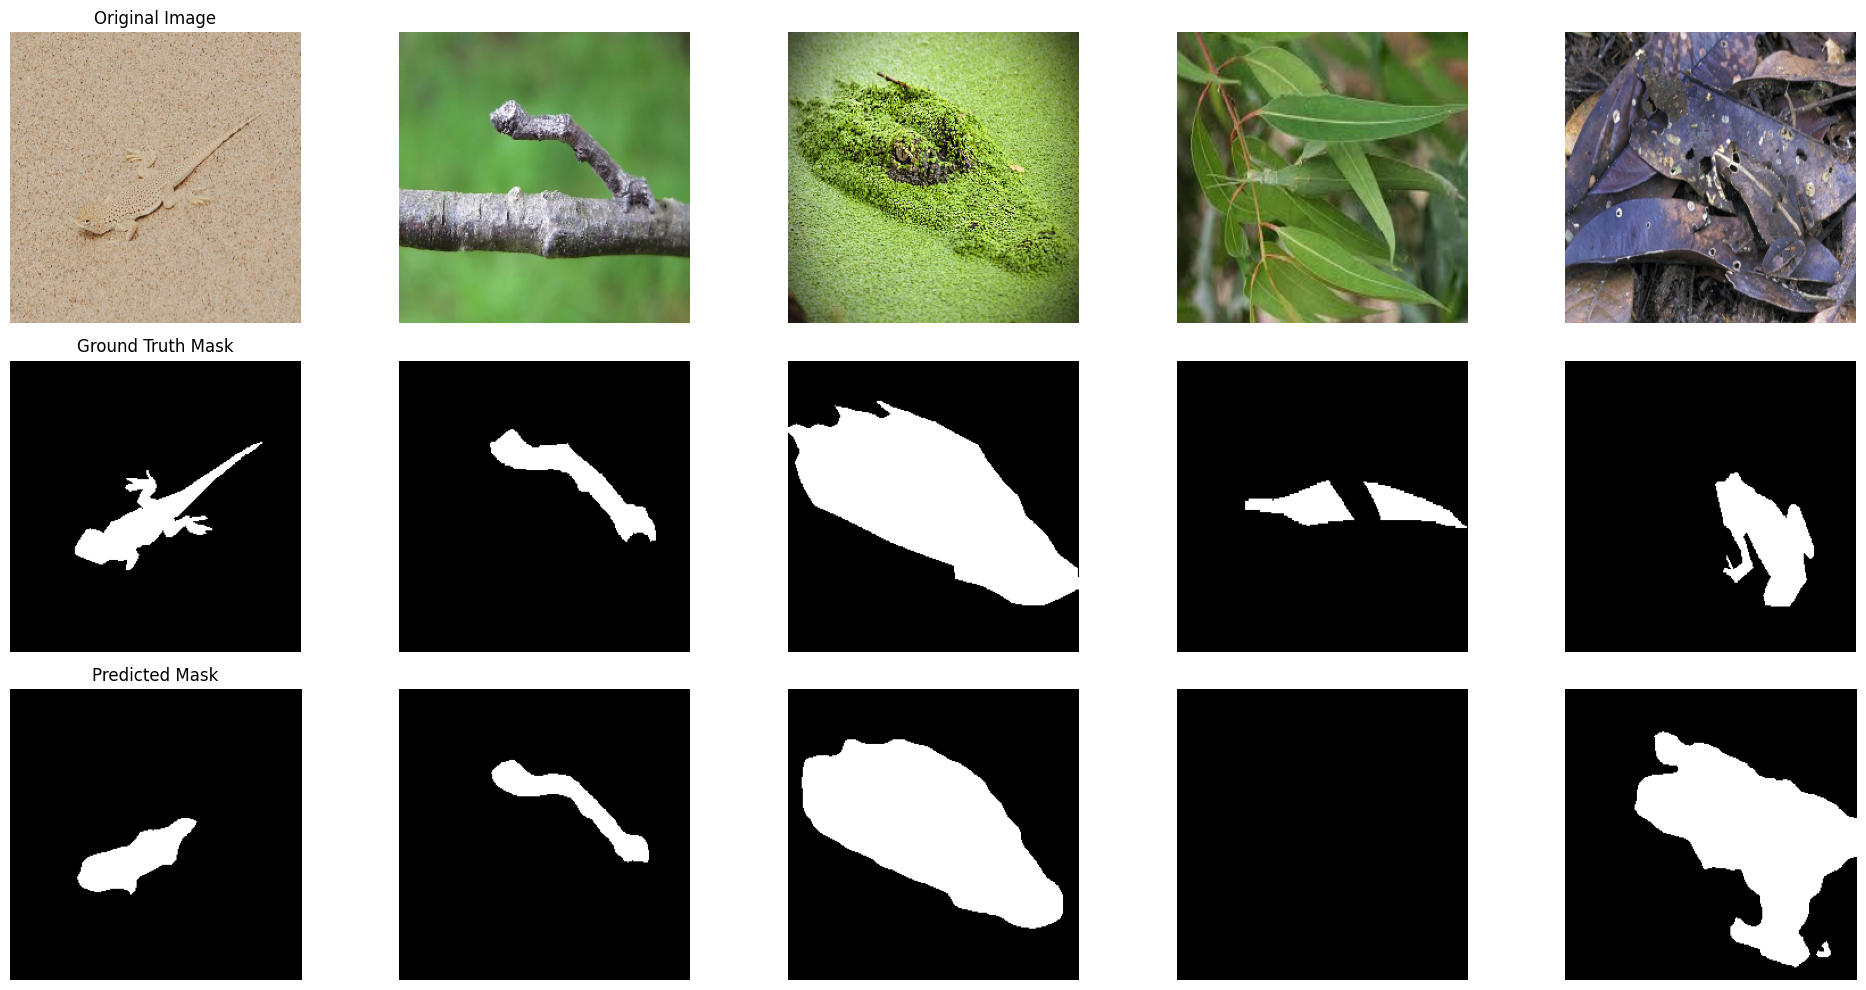

In [ ]:
_, test_transform = img_transform()

model_pth = "/kaggle/working/trained_model/model_best.pth"
num_classes = 2
device = "cuda" if torch.cuda.is_available() else "cpu"
data_path = "/kaggle/input/datasets/quanganhnguynquc/camodataset/CAMO-V.1.0-CVIU2019"

# Lưu ý: Các ID trong num_imgs phải nhỏ hơn tổng số ảnh trong tập Test của CAMO
pred_show_image_grid(
    model_pth=model_pth,
    device=device,
    test_transform=test_transform,
    num_classes=num_classes,
    num_imgs=[1, 10, 20, 30, 40], # Đã đổi list ID nhỏ lại để tránh lỗi Out of Range
    data_path=data_path
)